In [114]:
import numpy as np
# initialize A matrix
# np.random.seed(42)  # for reproducibility
# n_nodes = 5
# A = np.random.rand(n_nodes, n_nodes)
# A = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/55_1_suarez_MaMI_100_rougher_grid_animal_45/generated_networks/net_eta-1.9297618865966797_gamma-0.8877798318862915_ruleMatchingIndex.npy")[0]
# n_nodes = A.shape[0]    
# print(A, n_nodes)

# get a Albert-Barabasi network
from networkx import barabasi_albert_graph, to_numpy_array, erdos_renyi_graph
n_nodes = 100

density = 0.1 
num_edges = density * n_nodes * (n_nodes - 1) / 2
num_edges = int(num_edges)

num_edges_per_node = max(1, num_edges // n_nodes)

# A = to_numpy_array(barabasi_albert_graph(n_nodes, num_edges_per_node))
A = to_numpy_array(erdos_renyi_graph(n_nodes, density))
print(A, n_nodes)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]] 100


In [115]:
from nctpy.utils import matrix_normalization
system = 'discrete'
A_norm = matrix_normalization(A=A, c=1, system=system)
print(A_norm)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


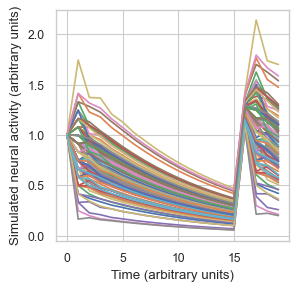

In [116]:
from nctpy.energies import sim_state_eq
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid', context='paper', font_scale=1)

T = 20  # time horizon
U = np.zeros((n_nodes, T))  # the input to the system
U[:,15] = 1  # impulse, 1 input at the first time point delivered to all nodes
B = np.eye(n_nodes)  # uniform full control set
x0 = np.ones((n_nodes, 1))  # initial state, all nodes set to 1 unit of neural activity
x = sim_state_eq(A_norm=A_norm, B=B, x0=x0, U=U, system=system)

# plot
f, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.plot(x.T)
ax.set_ylabel('Simulated neural activity (arbitrary units)')
ax.set_xlabel('Time (arbitrary units)')
f.savefig('A_stable.png', dpi=600, bbox_inches='tight', pad_inches=0.01)
plt.show()

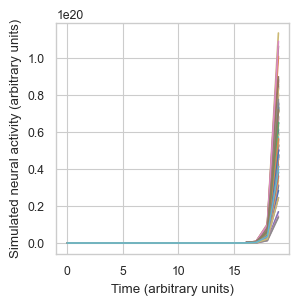

In [117]:
# unstable A
x = sim_state_eq(A_norm=A, B=B, x0=x0, U=U, system=system)

# plot
f, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.plot(x.T)
ax.set_ylabel('Simulated neural activity (arbitrary units)')
ax.set_xlabel('Time (arbitrary units)')
f.savefig('A_unstable.png', dpi=600, bbox_inches='tight', pad_inches=0.01)
plt.show()

In [118]:
from nctpy.metrics import ave_control
ac = ave_control(A_norm=A_norm, system=system)
print(ac)

[1.19954596 1.08279198 1.16128312 1.13062122 1.16003718 1.13913208
 1.08552455 1.07081775 1.31742955 1.12232124 1.15398675 1.18608622
 1.20972485 1.0922127  1.12036564 1.25539948 1.12014387 1.17462943
 1.10254513 1.13529008 1.08675581 1.15193663 1.10998837 1.18868008
 1.0992829  1.10093944 1.13803747 1.07230555 1.06762078 1.09548024
 1.1179464  1.09610237 1.05676492 1.06520469 1.03309779 1.09502939
 1.1614674  1.10104205 1.08718605 1.1463213  1.11997324 1.11959289
 1.17446008 1.07945011 1.10456784 1.15272278 1.13615499 1.12661342
 1.17620755 1.10005558 1.04770437 1.09439611 1.20321639 1.14322493
 1.04924914 1.16606944 1.20017298 1.14081464 1.11754816 1.06093838
 1.18090766 1.25264528 1.14853491 1.20019024 1.09163369 1.13395655
 1.13064845 1.09447903 1.07410558 1.07344268 1.08002435 1.06137159
 1.0975827  1.16702886 1.08680135 1.09826463 1.09355785 1.10269148
 1.19052661 1.10779272 1.16028887 1.0779231  1.15267383 1.09869638
 1.09881484 1.20315192 1.27287806 1.1646119  1.11651267 1.0889

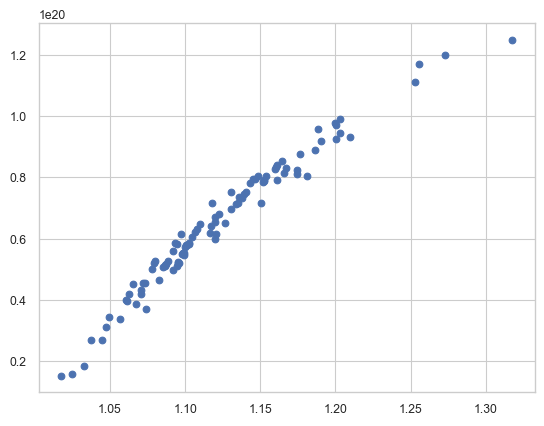

In [119]:
plt.scatter(ac, np.sum(x, axis=1))

In [120]:
# np.cumsum(np.sort(ac)[::-1]) <= 0.5 * sum(ac)
np.cumsum(np.sort(ac)[::-1]) <= 0.9 * sum(ac)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
       False, False, False, False, False, False, False, False, False,
       False])

In [121]:
# get the number of nodes whose sum of total avg control accounts for 90% of the total control
n_90 = np.sum(np.cumsum(np.sort(ac)[::-1]) <= 0.9 * sum(ac)) # + 1
print('number of nodes accounting for 90% of total control =', n_90)         

number of nodes accounting for 90% of total control = 89


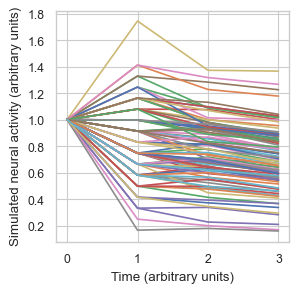

In [122]:
from nctpy.energies import sim_state_eq
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid', context='paper', font_scale=1)

T = 20  # time horizon
U = np.zeros((n_nodes, T))  # the input to the system
U[:,15] = 1  # impulse, 1 input at the first time point delivered to all nodes
B = np.eye(n_nodes)  # uniform full control set
x0 = np.ones((n_nodes, 1))  # initial state, all nodes set to 1 unit of neural activity
x = sim_state_eq(A_norm=A_norm, B=B, x0=x0, U=U, system=system)

# plot
f, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.plot(x.T[:4])
ax.set_ylabel('Simulated neural activity (arbitrary units)')
ax.set_xlabel('Time (arbitrary units)')
f.savefig('A_stable.png', dpi=600, bbox_inches='tight', pad_inches=0.01)
plt.show()

# See if calculating the span is interesting

In [125]:
system = 'continuous'
A_norm = matrix_normalization(A=A, c=1, system=system)
print(A_norm)

[[-1.  0.  0. ...  0.  0.  0.]
 [ 0. -1.  0. ...  0.  0.  0.]
 [ 0.  0. -1. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ... -1.  0.  0.]
 [ 0.  0.  0. ...  0. -1.  0.]
 [ 0.  0.  0. ...  0.  0. -1.]]


In [126]:
from nctpy.energies import get_control_inputs, integrate_u

# define initial and target states as random patterns of activity
np.random.seed(42)  # for reproducibility
x0 = np.random.rand(n_nodes, 1)  # initial state
xf = np.random.rand(n_nodes, 1)  # target state

# set parameters
T = 1  # time horizon
rho = 1  # mixing parameter for state trajectory constraint
S = np.eye(n_nodes)  # nodes in state trajectory to be constrained

# get the state trajectory (x) and the control inputs (u)
x, u, n_err = get_control_inputs(A_norm=A_norm, T=T, B=B, x0=x0, xf=xf, system=system, rho=rho, S=S)

In [127]:
# print errors
thr = 1e-8

# the first numerical error corresponds to the inversion error
print('inversion error = {:.2E} (<{:.2E}={:})'
      .format(n_err[0], thr, n_err[0] < thr))

# the second numerical error corresponds to the reconstruction error
print('reconstruction error = {:.2E} (<{:.2E}={:})'
      .format(n_err[1], thr, n_err[1] < thr))

inversion error = 2.64E-15 (<1.00E-08=True)
reconstruction error = 1.94E-13 (<1.00E-08=True)


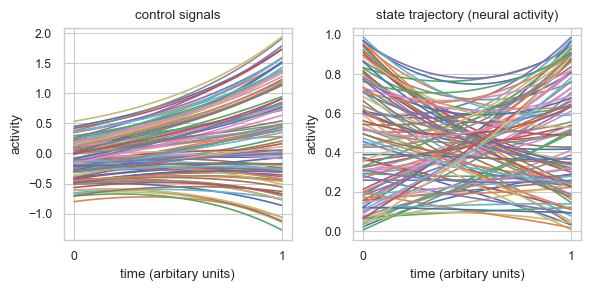

In [128]:
# plot x and u
f, ax = plt.subplots(1, 2, figsize=(6, 3))
# plot control signals for initial state
ax[0].plot(u)
ax[0].set_title('control signals')

# plot state trajectory for initial state
ax[1].plot(x)
ax[1].set_title('state trajectory (neural activity)')

for cax in ax.reshape(-1):
    cax.set_ylabel("activity")
    cax.set_xlabel("time (arbitary units)")
    cax.set_xticks([0, x.shape[0]])
    cax.set_xticklabels([0, T])

f.tight_layout()
f.savefig('plot_xu.png', dpi=600, bbox_inches='tight', pad_inches=0.01)
plt.show()

In [ ]:
# integrate control inputs to get control energy
node_energy = integrate_u(u)
print('node energy =', node_energy)

# summarize nodal energy to get control energy
energy = np.sum(node_energy)
print('energy = {:.2F}'.format(np.round(energy, 2)))

node energy = [2.19331110e+02 1.93584753e+01 5.67430880e+01 8.44957876e+00
 5.55705995e+02 7.43878657e-01 2.28316855e+01 2.91805185e+02
 1.17060233e+02 2.71795987e+02 3.99271871e+00 2.95761657e+02
 3.92185807e+02 3.69477229e+02 1.15399473e+02 1.00875581e+03
 4.56606040e+02 5.56780275e+01 5.37457726e+02 1.01673420e+02
 2.96036533e+02 1.00228985e+03 5.62119388e+01 3.43237849e+02
 6.54137137e+01 1.56417290e+01 8.13078325e+02 3.68675937e+02
 4.56301911e+02 4.72358848e+01 3.11763063e+01 5.01219920e+01
 1.05264486e+01 3.01345220e+02 3.66475199e+02 8.05609126e+01
 8.20863140e+00 6.15889334e+02 6.53832901e+00 9.38563246e+02
 1.00847548e+03 1.80223715e+01 1.56755232e+02 1.91764803e+02
 2.30951817e+01 5.91620802e+02 1.83241058e+02 1.56196525e+01
 3.76915997e+02 1.69398730e+01 2.53985184e+02 2.05744772e+02
 5.06076069e+02 2.28292827e+01 7.97446496e+02 2.64626246e+02
 3.07020773e+02 8.49119822e+02 3.59919341e+00 3.65407480e+02
 5.57932693e+01 1.44428097e+02 3.25111289e+01 9.84307386e+01
 4.8848171

In [ ]:
# get the number of nodes whose sum of control energy accounts for 90% of the total energy
n_90 = np.sum(np.cumsum(np.sort(node_energy)[::-1]) <= 0.9 * energy) # + 1
print('number of nodes accounting for 90% of total energy =', n_90)         

number of nodes accounting for 90% of total energy = 51


In [ ]:

class NullModelGenerator:
    """Generate various null models for connectome comparison."""
    
    @staticmethod
    def erdos_renyi(n_nodes, n_edges, weighted=False, weight_dist=None):
        """Erdős-Rényi random graph with same number of nodes and edges."""
        G = nx.gnm_random_graph(n_nodes, n_edges)
        A = nx.to_numpy_array(G)
        
        if weighted and weight_dist is not None:
            # Sample weights from empirical distribution
            edge_mask = A > 0
            n_edges_actual = int(edge_mask.sum())
            weights = np.random.choice(weight_dist, size=n_edges_actual)
            A[edge_mask] = weights
        
        return A
    
    @staticmethod
    def configuration_model(degree_sequence, weighted=False, weight_dist=None):
        """Configuration model preserving degree sequence."""
        # Ensure degree sequence is valid
        if sum(degree_sequence) % 2 != 0:
            degree_sequence[-1] += 1
        
        try:
            G = nx.configuration_model(degree_sequence)
            G = nx.Graph(G)  # Remove multi-edges and self-loops
            G.remove_edges_from(nx.selfloop_edges(G))
            A = nx.to_numpy_array(G)
            
            if weighted and weight_dist is not None:
                edge_mask = A > 0
                n_edges = int(edge_mask.sum())
                weights = np.random.choice(weight_dist, size=n_edges)
                A[edge_mask] = weights
            
            return A
        except:
            # Fallback to ER if configuration model fails
            n_edges = sum(degree_sequence) // 2
            return NullModelGenerator.erdos_renyi(len(degree_sequence), n_edges, weighted, weight_dist)
    
    @staticmethod
    def watts_strogatz(n_nodes, k, p, weighted=False, weight_dist=None):
        """Watts-Strogatz small-world model."""
        try:
            G = nx.watts_strogatz_graph(n_nodes, k, p)
            A = nx.to_numpy_array(G)
            
            if weighted and weight_dist is not None:
                edge_mask = A > 0
                n_edges = int(edge_mask.sum())
                weights = np.random.choice(weight_dist, size=n_edges)
                A[edge_mask] = weights
            
            return A
        except:
            # Fallback
            n_edges = (n_nodes * k) // 2
            return NullModelGenerator.erdos_renyi(n_nodes, n_edges, weighted, weight_dist)
    
    @staticmethod
    def geometric_random(n_nodes, n_edges, distance_matrix=None, weighted=False, weight_dist=None):
        """Spatial/geometric random graph based on distance matrix."""
        if distance_matrix is None:
            # Random spatial positions
            positions = np.random.rand(n_nodes, 3)
            distance_matrix = np.linalg.norm(positions[:, None] - positions[None, :], axis=2)
        
        # Create probability matrix (closer = higher probability)
        max_dist = distance_matrix.max()
        prob_matrix = 1 - (distance_matrix / max_dist)
        np.fill_diagonal(prob_matrix, 0)
        
        # Normalize to get target number of edges
        prob_matrix_flat = prob_matrix[np.triu_indices(n_nodes, k=1)]
        prob_matrix_flat /= prob_matrix_flat.sum()
        
        # Sample edges
        edge_indices = np.random.choice(len(prob_matrix_flat), size=n_edges, 
                                       replace=False, p=prob_matrix_flat)
        
        A = np.zeros((n_nodes, n_nodes))
        triu_indices = np.triu_indices(n_nodes, k=1)
        selected_edges = (triu_indices[0][edge_indices], triu_indices[1][edge_indices])
        
        if weighted and weight_dist is not None:
            weights = np.random.choice(weight_dist, size=n_edges)
            A[selected_edges] = weights
            A = A + A.T
        else:
            A[selected_edges] = 1
            A = A + A.T
        
        return A
    
    @staticmethod
    def weight_shuffled(A_original):
        """Shuffle weights while preserving topology."""
        A = A_original.copy()
        weights = A[A > 0].copy()
        np.random.shuffle(weights)
        A[A > 0] = weights
        return A